<a href="https://colab.research.google.com/github/sdtasneem/AIDS-Projects/blob/main/Restaurant_Review_Sentiment_Analysis_using_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries for downloading the dataset and performing data analysis
import kagglehub
import os
import pandas as pd

In [ ]:
# Download the restaurant review dataset from Kaggle
# Locate the TSV file and load it into a Pandas DataFrame
path = kagglehub.dataset_download("d4rklucif3r/restaurant-reviews")
file=os.path.join(path,'Restaurant_Reviews.tsv')
df=pd.read_csv(file,delimiter="\t")

100%|██████████| 24.1k/24.1k [00:00<00:00, 31.8MB/s]

Extracting files...


In [ ]:
# Display the 5 first few rows to understand the dataset structure
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [ ]:
# Check for missing values in each column
df.isnull().sum()

,0
Review,0
Liked,0


In [ ]:
# Check the number of rows and columns in the dataset
df.shape

(1000, 2)

In [ ]:
# Count duplicate reviews in the dataset
df.duplicated().sum()

np.int64(4)

In [ ]:
# Remove duplicate reviews to avoid repeated samples during model training
df.drop_duplicates(inplace=True)

In [ ]:
# Define a function to clean the review text
# Convert text to lowercase
# Remove special characters and extra spaces
import re
def clean_text(text):
  text=text.lower()
  text=re.sub(r'[^a-zA-Z\s]','',text)
  text=" ".join(text.split())
  return text

In [ ]:
# Apply the text cleaning function to every restaurant review
df['Review']=df['Review'].apply(clean_text)

In [ ]:
# Display the cleaned review text
df['Review']

,Review
0,wow loved this place
1,crust is not good
2,not tasty and the texture was just nasty
3,stopped by during the late may bank holiday of...
4,the selection on the menu was great and so wer...
...,...
995,i think food should have flavor and texture an...
996,appetite instantly gone
997,overall i was not impressed and would not go back
998,the whole experience was underwhelming and i t...


In [ ]:
# Define the maximum vocabulary size and maximum review length
MAX_FEATURES=1000
MAX_LENGTH=100

In [ ]:
# Separate the review text as input features
# Use the Liked column as the sentiment target
x=df['Review']
y=df['Liked']

In [ ]:
# Import tools for converting text into numerical sequences
# Padding is used to make all review sequences the same length
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# Create a tokenizer with a vocabulary limit of 1000 words
# Use an OOV token for words not present in the vocabulary
# Learn the vocabulary from the restaurant reviews
token=Tokenizer(num_words=1000,oov_token='<OOV>')
token.fit_on_texts(x)


In [ ]:
# Convert each review into a sequence of numerical word indices
# Pad or truncate sequences to a fixed length of 100
sequence=token.texts_to_sequences(x)
pad=pad_sequences(sequence,maxlen=MAX_LENGTH,padding='post',truncating='post')

In [ ]:
# Split the data into training and testing sets
# Use stratification to preserve the sentiment class distribution
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(pad,y,test_size=0.2,stratify=y)

In [ ]:
# Import layers required to build the RNN sentiment classification model
from tensorflow.keras.layers import Dense,SimpleRNN,Dropout,Embedding
from tensorflow.keras import models

In [ ]:
# Check the shape of the training input data
x_train.shape

(796, 100)

In [ ]:
# Check the shape of the training target labels
y_train.shape

(796,)

In [ ]:
# Define the RNN architecture for sentiment classification
def rnn():
  model=models.Sequential([
  Embedding(input_dim=MAX_FEATURES,output_dim=128,input_length=MAX_LENGTH),
  SimpleRNN(units=32,return_sequences=False),
  Dropout(0.2),
  Dense(64,activation='relu'),
  Dense(32,activation='relu'),
  Dense(1,activation='sigmoid')
  ])
  return model

In [ ]:
# Create an instance of the RNN sentiment classification model
initial_model=rnn()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Compile the model using Adam optimizer
# Binary cross-entropy is used because the task has two sentiment classes
# Accuracy is used to monitor classification performance
initial_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
# Use EarlyStopping to stop training when validation loss stops improving
# Restore the model weights from the best-performing epoch
from tensorflow.keras.callbacks import EarlyStopping
callback=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

In [ ]:
# Train the RNN model using the training dataset
# Reserve 20% of the training data for validation
# Early stopping helps prevent unnecessary training and overfitting
history=initial_model.fit(
    x_train,y_train,epochs=300,validation_split=0.20,
    callbacks=[callback]
)

Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7612 - loss: 0.5212 - val_accuracy: 0.5375 - val_loss: 0.8199
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7430 - loss: 0.5326 - val_accuracy: 0.5125 - val_loss: 0.8239
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8249 - loss: 0.4677 - val_accuracy: 0.5312 - val_loss: 0.8737
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9020 - loss: 0.3135 - val_accuracy: 0.5625 - val_loss: 1.0732


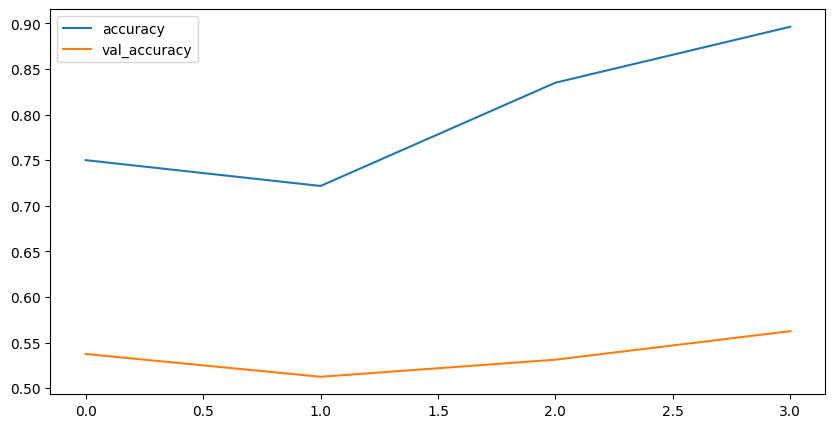

In [ ]:
# Plot training and validation accuracy
# Compare model performance across training epochs
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.show()

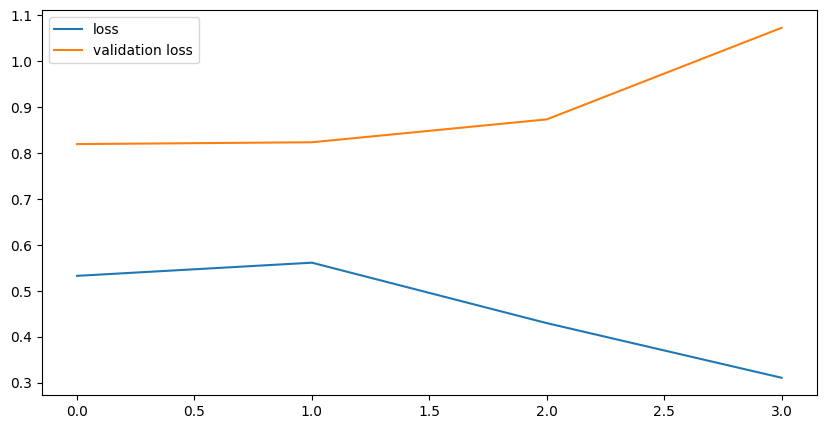

In [ ]:
# Plot training and validation loss
# Monitor how the model's prediction error changes during training
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.legend()
plt.show()

In [ ]:
# Save the trained tokenizer so the same text preprocessing
# can be reused when making predictions on new reviews
import pickle
with open("food review.pkl","wb") as f:
  pickle.dump(token,f)

In [ ]:
# Save the trained RNN model for future inference
initial_model.save('restuart food reviews.h5')

In [ ]:
# Import the function required to load the saved RNN model
from tensorflow.keras.models import load_model

In [ ]:
# Load the trained sentiment classification model
# Load the saved tokenizer used during model training
# This ensures new reviews use the same preprocessing pipeline
loaded_model=load_model('restuart food reviews.h5')
with open("food review.pkl",'rb') as f:
  load_token=pickle.load(f)

In [ ]:
# Define a function to predict the sentiment of a new restaurant review
# The function cleans, tokenizes, pads, and classifies the input text
def predict_sentiment(text):
  clean=clean_text(text)
  sequence=load_token.texts_to_sequences([clean])
  padded=pad_sequences(sequence,maxlen=MAX_LENGTH,padding='post')
  probability=loaded_model.predict(padded)
  sentiment ='positive ' if probability>0.5 else "negative"
  return sentiment,probability

In [ ]:
# Define a new restaurant review for testing the prediction pipeline
text='i love this good taste but to much cost'

In [ ]:
# Predict the sentiment of the new restaurant review
predict_sentiment(text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


('positive ', array([[0.74465865]], dtype=float32))